#### Dataset Exploration

Analyze the structure of the dataset and separate its components into csv

In [15]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset("acon96/Home-Assistant-Requests")
df_train = dataset["train"].to_pandas()
df_test = dataset["test"].to_pandas()

In [16]:
display(df_train.head())
display(df_test.head())

,conversations
0,"[{'from': 'system', 'value': 'You are 'Al', a ..."
1,"[{'from': 'system', 'value': 'You are 'Al', a ..."
2,"[{'from': 'system', 'value': 'You are 'Al', a ..."
3,"[{'from': 'system', 'value': 'You are 'Al', a ..."
4,"[{'from': 'system', 'value': 'You are 'Al', a ..."


,conversations
0,"[{'from': 'system', 'value': 'You are 'Al', a ..."
1,"[{'from': 'system', 'value': 'You are 'Al', a ..."
2,"[{'from': 'system', 'value': 'You are 'Al', a ..."
3,"[{'from': 'system', 'value': 'You are 'Al', a ..."
4,"[{'from': 'system', 'value': 'You are 'Al', a ..."


In [17]:
def extract_action_type(conversation_list):
    text = str(conversation_list)
    # Basic logic to find the service call within the generated text block
    if '"service":' in text:
        return "Home Assistant Service Call"
    return "Standard Conversational Reply"

df_train['action_type'] = df_train['conversations'].apply(extract_action_type)
df_test['action_type'] = df_test['conversations'].apply(extract_action_type)

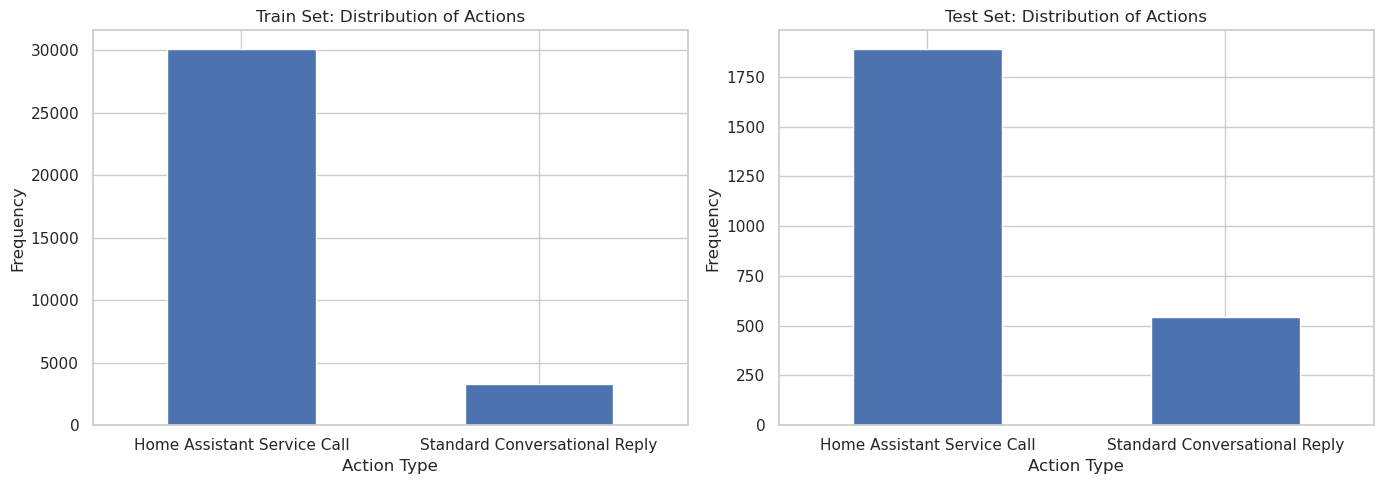

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_train['action_type'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Train Set: Distribution of Actions')
axes[0].set_xlabel('Action Type')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=0)

df_test['action_type'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Test Set: Distribution of Actions')
axes[1].set_xlabel('Action Type')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [19]:
import json
import re

def extract_data(data_split):
    # TODO: merge train and test data because same user commands can't be on both sets
    domains = []
    services = []
    entities = []
    assistant_texts = []
    assistant_payloads = []
    user_commands = []
    for row in data_split:
        conversations = row.get("conversations", [])
        if not re.search(r"You are 'Al'", conversations[0].get("value", "")) or not conversations:
            continue
        for turn in conversations:
            role = turn.get("from")
            text = turn.get("value", "")
            if role == "user":
                user_commands.append(text)
            if role == "assistant":
                match = re.search(r'```homeassistant\n(.*?)\n```', text, re.DOTALL)
                if match:
                    json_str = match.group(1)
                    pre_text = text[:match.start()].strip()
                    assistant_texts.append(pre_text or "") # Store pre-JSON text if it exists, otherwise empty string
                    parsed_payloads = []
                    try:
                        parsed_payloads.append(json.loads(json_str))
                    except json.JSONDecodeError:
                        for line in json_str.split("\n"):
                            if line.strip():
                                try:
                                    parsed_payloads.append(json.loads(line))
                                except json.JSONDecodeError:
                                    pass
                    if parsed_payloads:
                        assistant_payloads.append(json_str) # Store the entire JSON payload
                        for payload in parsed_payloads:
                            service_call = payload.get("service", "")
                            if isinstance(service_call, str) and "." in service_call:
                                domain = service_call.split(".")[0]
                                domains.append(domain)
                                services.append(service_call)

                            entity_id = payload.get("target_device")
                            if isinstance(entity_id, str):
                                entities.append(entity_id)
                            elif isinstance(entity_id, list):
                                entities.extend(entity_id)
                    else:
                        assistant_payloads.append("{}")
                else:
                    assistant_texts.append(text)
                    assistant_payloads.append("{}")
    return domains, services, entities, user_commands, assistant_texts, assistant_payloads

train_domains, train_services, train_entities, train_commands, train_ass_texts, train_ass_payloads = extract_data(dataset["train"])
test_domains, test_services, test_entities, test_commands, test_ass_texts, test_ass_payloads = extract_data(dataset["test"])

def get_items(items_list):
    if not items_list: return pd.Series(dtype='float64')
    return pd.Series(items_list).value_counts()#.head(10)

dom_train = get_items(train_domains)
svc_train = get_items(train_services)
ent_train = get_items(train_entities)
cmd_train = get_items(train_commands)
txt_train = get_items(train_ass_texts)
pay_train = get_items(train_ass_payloads)

dom_test = get_items(test_domains)
svc_test = get_items(test_services)
ent_test = get_items(test_entities)
cmd_test = get_items(test_commands)
txt_test = get_items(test_ass_texts)
pay_test = get_items(test_ass_payloads)

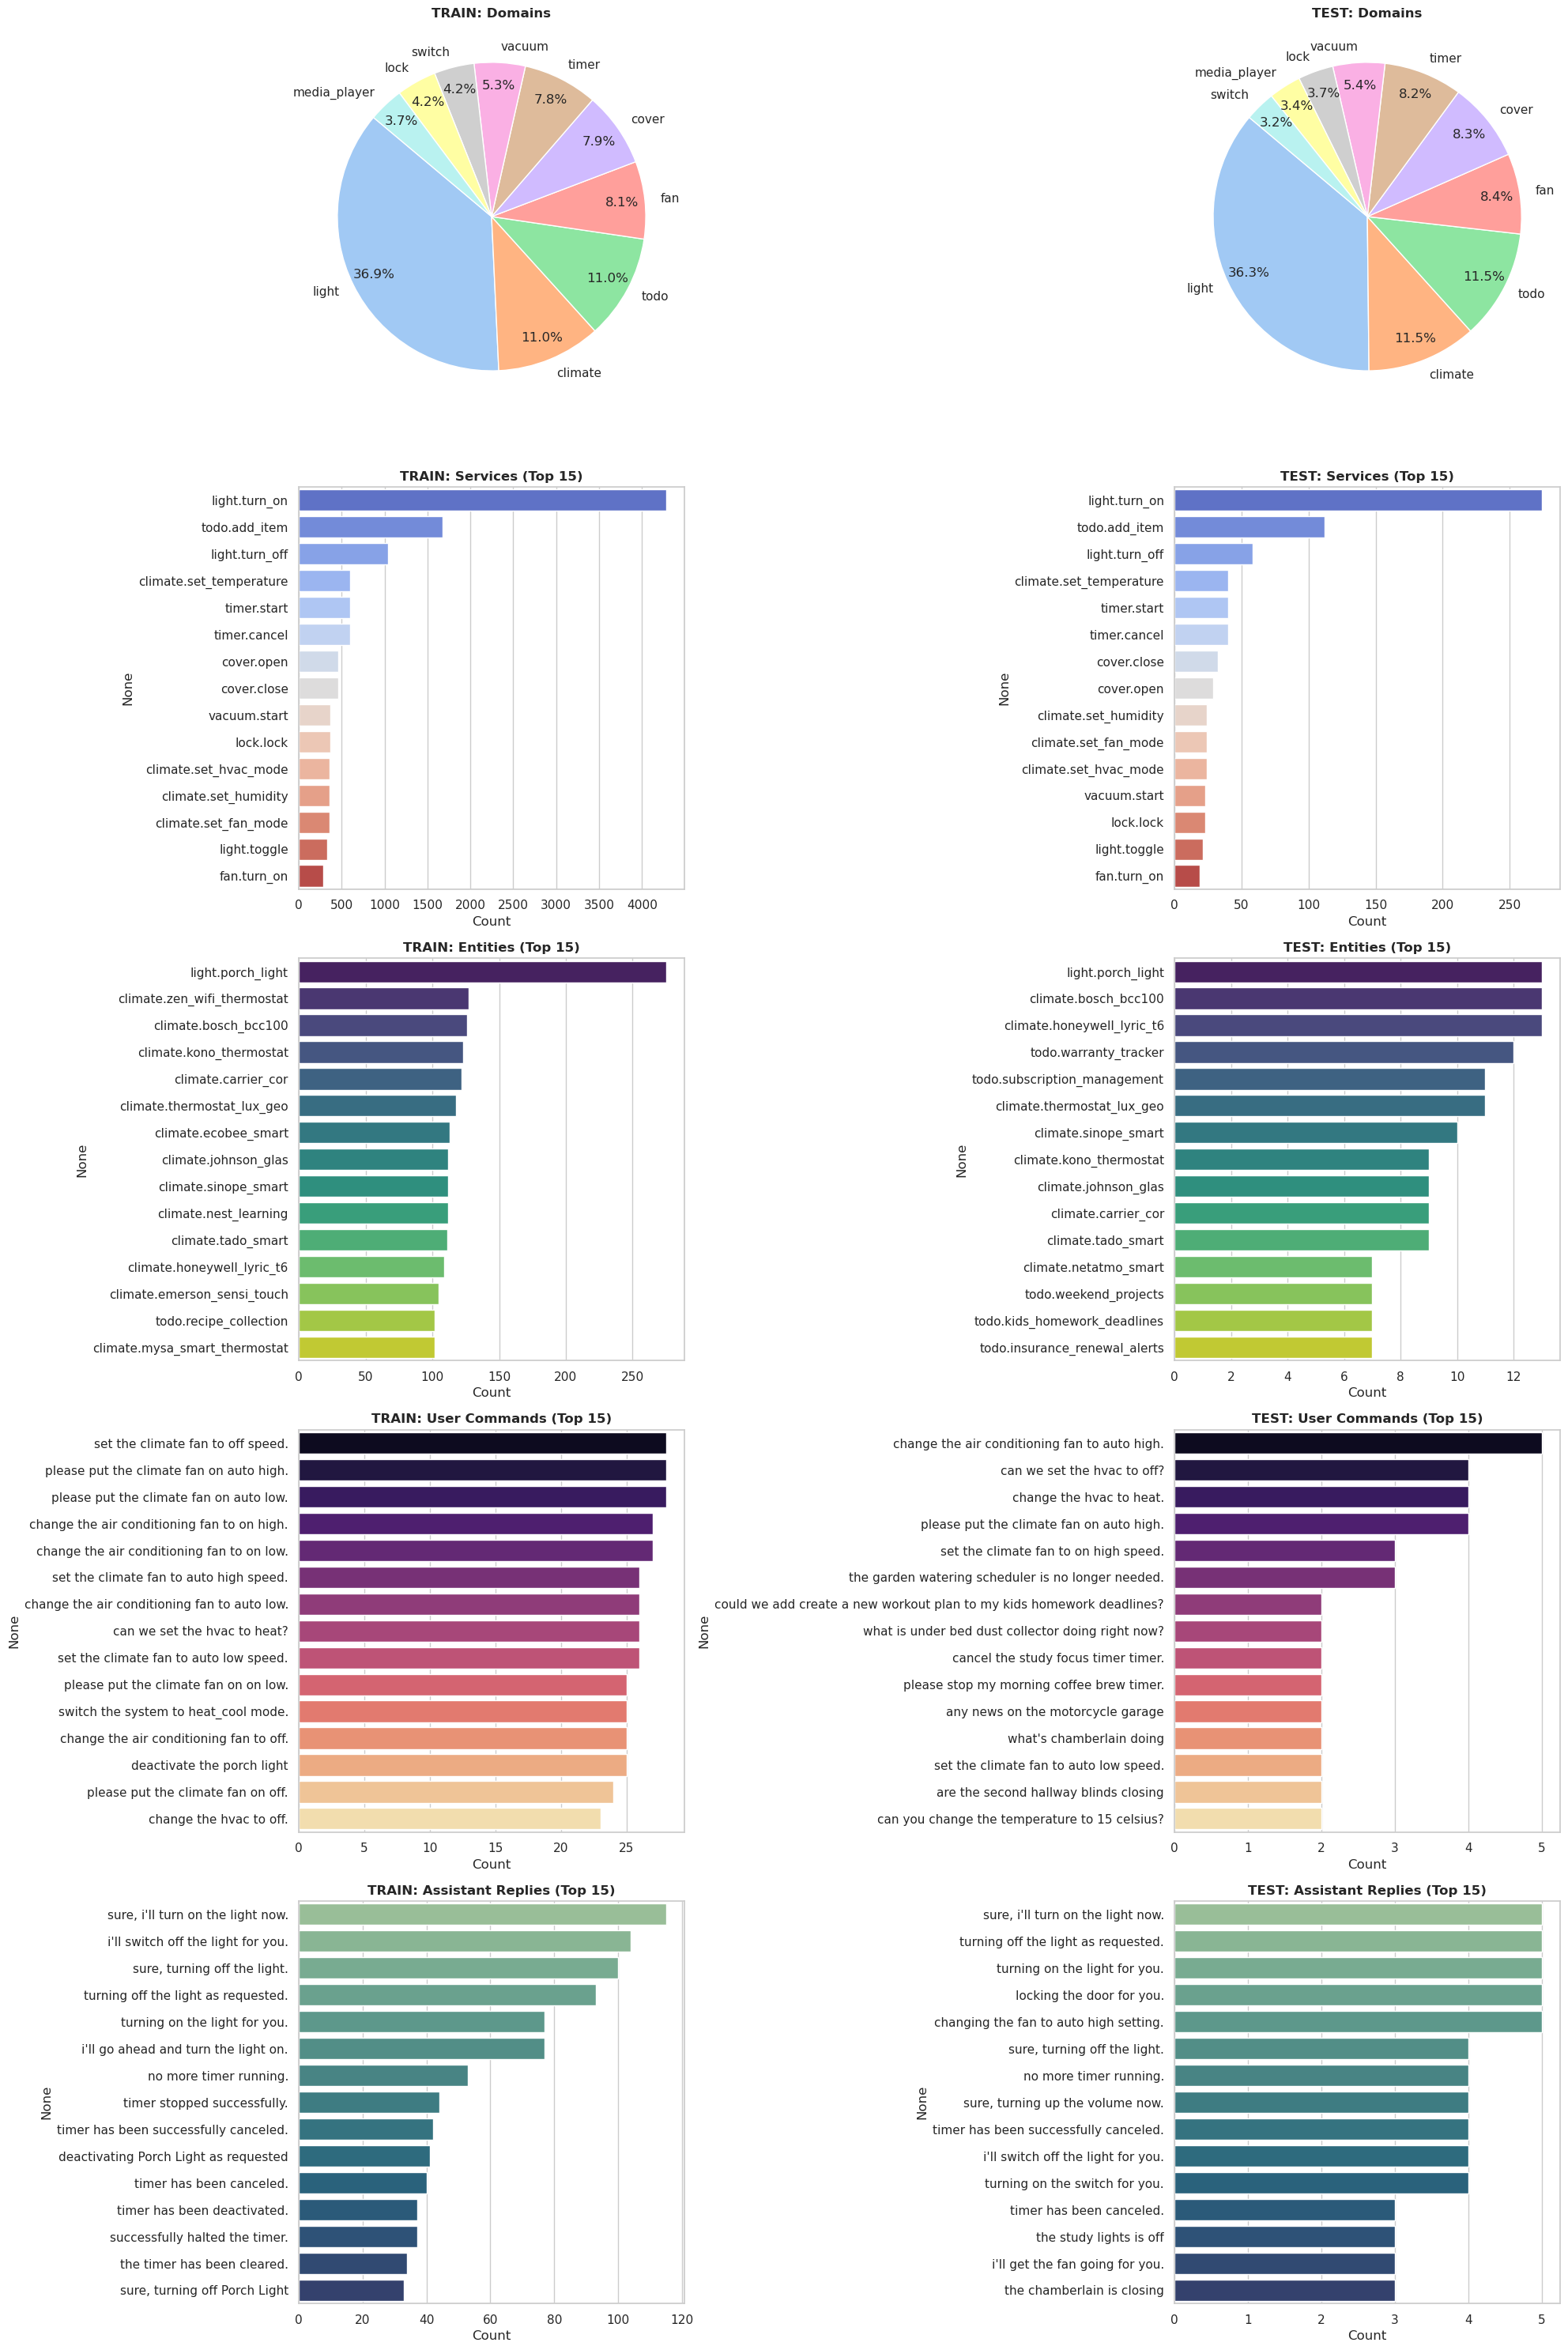

In [20]:
from matplotlib import ticker
import seaborn as sns

PLOT_LIMIT = 15
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(5, 2, figsize=(20, 30))

def plot_bar_safe(data, ax, title, color_palette="viridis", limit=PLOT_LIMIT):
    if data.empty:
        ax.text(0.5, 0.5, "No Data", ha='center')
        return
    subset = data.head(limit)
    sns.barplot(x=subset.values, y=subset.index, ax=ax, palette=color_palette, hue=subset.index, legend=False)
    ax.set_title(f"{title} (Top {limit})", fontsize=12, fontweight='bold')
    ax.set_xlabel('Count')

def plot_pie_safe(data, ax, title):
    if data.empty:
        ax.text(0.5, 0.5, "No Data", ha='center')
        return
    if len(data) > 15:
        top_slice = data.head(15)
        others = pd.Series([data.iloc[15:].sum()], index=['Others'])
        data_to_plot = pd.concat([top_slice, others])
    else:
        data_to_plot = data
    ax.pie(data_to_plot.values, labels=data_to_plot.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"), pctdistance=0.85)

    ax.set_title(title, fontsize=12, fontweight='bold')

# Row 0: Domains
plot_pie_safe(dom_train, axes[0, 0], 'TRAIN: Domains')
plot_pie_safe(dom_test, axes[0, 1], 'TEST: Domains')
# Row 1: Services
plot_bar_safe(svc_train, axes[1, 0], 'TRAIN: Services', "coolwarm")
plot_bar_safe(svc_test, axes[1, 1], 'TEST: Services', "coolwarm")
# Row 2: Entities
plot_bar_safe(ent_train, axes[2, 0], 'TRAIN: Entities', "viridis")
plot_bar_safe(ent_test, axes[2, 1], 'TEST: Entities', "viridis")
# Row 3: User Commands
plot_bar_safe(cmd_train, axes[3, 0], 'TRAIN: User Commands', "magma")
plot_bar_safe(cmd_test, axes[3, 1], 'TEST: User Commands', "magma")
# Row 4: Assistant Replies
plot_bar_safe(txt_train, axes[4, 0], 'TRAIN: Assistant Replies', "crest")
plot_bar_safe(txt_test, axes[4, 1], 'TEST: Assistant Replies', "crest")

plt.tight_layout()
plt.show()

In [21]:
cmd_train.to_csv("./data/commands_train.csv", header=["Count"], index_label="Command")
txt_train.to_csv("./data/assistant_texts_train.csv", header=["Count"], index_label="Text")
pay_train.to_csv("./data/assistant_payloads_train.csv", header=["Count"], index_label="Payload")
dom_train.to_csv("./data/domains_train.csv", header=["Count"], index_label="Domain")
svc_train.to_csv("./data/services_train.csv", header=["Count"], index_label="Service")
ent_train.to_csv("./data/entities_train.csv", header=["Count"], index_label="Entity")

cmd_test.to_csv("./data/commands_test.csv", header=["Count"], index_label="Command")
txt_test.to_csv("./data/assistant_texts_test.csv", header=["Count"], index_label="Text")
pay_test.to_csv("./data/assistant_payloads_test.csv", header=["Count"], index_label="Payload")
dom_test.to_csv("./data/domains_test.csv", header=["Count"], index_label="Domain")
svc_test.to_csv("./data/services_test.csv", header=["Count"], index_label="Service")
ent_test.to_csv("./data/entities_test.csv", header=["Count"], index_label="Entity")
# Wrapping them in pd.Series() first prevents fatal errors if the entity lists
# are a different length than your domains due to your 'extend' logic.
df_raw_train = pd.DataFrame({
    "User_Command": pd.Series(train_commands),
    "Assistant_Text": pd.Series(train_ass_texts),
    "Assistant_Payload": pd.Series(train_ass_payloads)
})
df_raw_train.to_csv("./data/cleaned_raw_train.csv", index=False)

df_raw_test = pd.DataFrame({
    "User_Command": pd.Series(test_commands),
    "Assistant_Text": pd.Series(test_ass_texts),
    "Assistant_Payload": pd.Series(test_ass_payloads)
})
df_raw_test.to_csv("./data/cleaned_raw_test.csv", index=False)